### Import Packages

In [3]:
# General data handling
import pandas as pd
import numpy as np
import duckdb
import sklearn

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sentence Transformers
import transformers
from sentence_transformers import SentenceTransformer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# Validation 
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     cross_validate, cross_val_predict, train_test_split)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay,
                             auc, make_scorer, recall_score, precision_score)

# Other helpers
from scipy.stats import loguniform
import joblib
from tqdm import tqdm

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the data

In [23]:
# Connect to DuckDB database
db = duckdb.connect(database='patents_training.db')

In [3]:
db.sql("SHOW TABLES")

┌─────────────┐
│    name     │
│   varchar   │
├─────────────┤
│ patents_raw │
└─────────────┘

In [ ]:
# db.sql("""
#     CREATE OR REPLACE TABLE publications_new_training (
#         id VARCHAR PRIMARY KEY,
#         title VARCHAR,
#         abstract VARCHAR,
#         year INT,
#         scope VARCHAR,
#         pillar VARCHAR,
#         research_category VARCHAR
#     )
# """)

# # Step 2: load the CSV into it
# db.sql("INSERT INTO publications_new_training SELECT id, title, abstract, year, scope, pillar, research_category FROM '../new_training_data.csv'")

In [16]:
# Convert raw data to pandas dataframe
data = db.sql("SELECT * FROM patents_raw").df()

In [ ]:
# Filter out entries without abstract (shouldn't be necessary, training data already filtered)
data = data[~data['abstract'].isna()]

In [18]:
# Concatenate title and abstract for input into sentence transformer
data['text'] = data['title'] + ' [SEP] ' + data['abstract']

In [17]:
# inspect data
print(len(data))
data.head()

2450


,id,family_id,application_number,title,abstract,cpc,publication_year,jurisdiction,scope,pillar,subpillar,research_category,endproduct,ingredient,truncated
0,US-11540543-B2,38969498,US17036785,Sweetened consumables comprising mogroside IV ...,Disclosed are sweetened consumables and method...,"['A23L29/37', 'A23L29/30', 'A23L33/105', 'A23L...",2023,US,out,NaN,NaN,NaN,NaN,NaN,False
1,US-20210015134-A1,38969498,US17036785,CONSUMABLES,Disclosed are sweetened consumables and method...,"['A23L27/30', 'A23L2/60', 'A23V2002/00', 'A23L...",2021,US,out,NaN,NaN,NaN,NaN,NaN,False
2,US-20170298457-A1,42829610,US15360298,LACTIC BACTERIUM WITH MODIFIED GALACTOKINASE E...,The present invention relates to a bacterial c...,"['A23C19/0323', 'C12N9/1205', 'A23C2220/206', ...",2017,US,in,PB,NaN,Strain development,Yoghurt and fermented dairy,NaN,False
3,EP-2473058-A1,42829610,EP10751643A,LACTIC BACTERIUM WITH MODIFIED GALACTOKINASE E...,The present invention relates to a bacterial c...,"['A23C19/0323', 'C12R2001/46', 'C12Y207/01006'...",2012,EP,in,PB,NaN,Strain development,Yoghurt and fermented dairy,NaN,False
4,EP-3542638-A1,44510082,EP19173302.1,NUTRITIONAL COMPOSITION,Non-medical use of at least two components sel...,"['A23L33/13', 'A61K33/04', 'A23L33/40', 'A61K3...",2019,EP,out,NaN,NaN,NaN,NaN,NaN,False


False

### Sentence Transformer to generate text embeddings

In [13]:
# Load model
model = SentenceTransformer('AI-Growth-Lab/PatentSBERTa')

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Viola Hollek\.cache\huggingface\hub\models--AI-Growth-Lab--PatentSBERTa. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [14]:
# Check token lengths
# Access tokenizer from within the loaded SentenceTransformer
tokenizer = model.tokenizer

# Count tokens for each text (title + abstract combined)
token_count = data['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

# Summary statistics
print(token_count.describe())
print(f"\nTexts exceeding 512 tokens: {(token_count > 512).sum()} "
      f"({(token_count > 512).mean():.1%})")

Token indices sequence length is longer than the specified maximum sequence length for this model (654 > 512). Running this sequence through the model will result in indexing errors


count    2450.000000
mean      148.338367
std        90.404767
min        22.000000
25%        86.000000
50%       128.000000
75%       194.000000
max      1382.000000
Name: text, dtype: float64

Texts exceeding 512 tokens: 16 (0.7%)


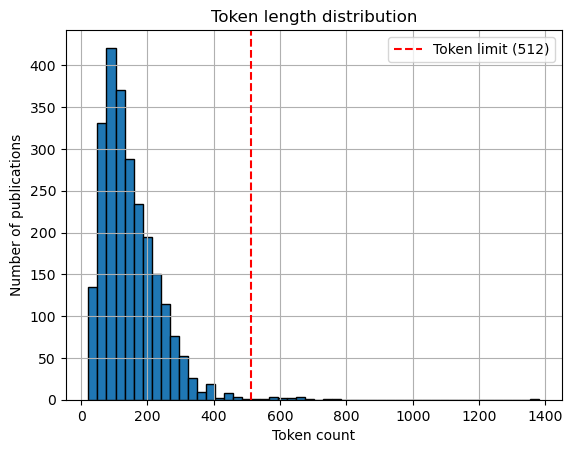

In [15]:
# Visualise distribution
token_count.hist(bins=50, edgecolor='black')
plt.axvline(512, color='red', linestyle='--', label='Token limit (512)')
plt.xlabel('Token count')
plt.ylabel('Number of publications')
plt.title('Token length distribution')
plt.legend()
plt.show()

In [16]:
# Leave entries with excessively long token counts for now, they will be automatically truncated by the model
# Store information about truncation in the dataset to check these entries later
data['truncated'] = token_count > 512

In [17]:
# add the truncated label to database
db.sql("ALTER TABLE patents_raw ADD COLUMN IF NOT EXISTS truncated BOOLEAN")

db.register("df_temp", data)  
db.sql("""
    UPDATE patents_raw
    SET truncated = df_temp.truncated
    FROM df_temp
    WHERE patents_raw.id = df_temp.id
""")

In [ ]:
# Get embeddings (this is done in separate file because of runtime)
# embeddings = model.encode(data['text'].tolist())

In [ ]:
# save embeddings
# np.save('patentsberta_embeddings_checkpoint.npy', embeddings)

In [25]:
# save embeddings to database to safely store alongside data
data['embedding'] = list(embeddings)
db.sql("CREATE OR REPLACE TABLE patents_embeddings AS SELECT id, embedding FROM data")

### Split data into train and test data

In [24]:
# Load embeddings 
embeddings = np.load('patentsberta_embeddings_checkpoint.npy')

In [73]:
# For now only stratify by scope and pillar
data['pillar'] = data['pillar'].fillna('NA')
data['stratify_label'] = data['scope'] + data['pillar']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, data,
    test_size=0.2,
    random_state=42,
    stratify=data['stratify_label']
)


In [34]:
print(y_train['stratify_label'].value_counts())

print(y_test['stratify_label'].value_counts())

stratify_label
outNA    940
inPB     666
inF      137
inCM     137
inCC      80
Name: count, dtype: int64
stratify_label
outNA    235
inPB     166
inCM      35
inF       34
inCC      20
Name: count, dtype: int64


### Classification of in/out of scope

In [30]:
# Convert scope to binary integer class
y_train_scope = (y_train['scope'] == 'in').astype(int)
y_test_scope  = (y_test['scope']  == 'in').astype(int)

#### Test hyperparameters and models

In [35]:
# Set up validation metrics
## specificity isn't natively integrated, define function:
specificity_scorer = make_scorer(recall_score, pos_label=0)
npv_scorer = make_scorer(precision_score, pos_label=0)

scoring = {
    'precision':    'precision', # = TP / (TP + FP)
    'recall':       'recall', # = sensitivity = TP / (TP + FN)
    'specificity':  specificity_scorer, # = TN / (TN + FP)
    'npv':          npv_scorer, # = TN / (TN + FN)
    'f1':           'f1' # 2 × (precision × recall) / (precision + recall)
}

In [36]:
# Test hyperparameters of Logistic Regression model using cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs', 'liblinear', 'newton-cholesky']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                    param_grid, cv=cv, scoring=scoring, refit='npv', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'C': 100, 'solver': 'liblinear'}


In [ ]:
# save results to data frame
lr_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_C', 'param_solver',  
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
lr_grid[cols]

## class_weight is clearly better with class_weight = 'balanced'
## the best C = 100, solver = "liblinear"

lr_grid[cols].to_csv('PatentSBERTa_LR_grid.csv')

In [48]:
cols = ['param_C', 'param_solver',  
        'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 
        'mean_test_specificity', 'mean_test_npv']
lr_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_C,param_solver,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_specificity,mean_test_npv
10,100.0,liblinear,0.883233,0.881373,0.882250,0.873404,0.871609
9,100.0,lbfgs,0.884609,0.879412,0.881995,0.875532,0.870015
11,100.0,newton-cholesky,0.884609,0.879412,0.881995,0.875532,0.870015
13,1000.0,liblinear,0.886111,0.875490,0.880676,0.877660,0.866730
8,10.0,newton-cholesky,0.879044,0.875490,0.877224,0.869149,0.865496
12,1000.0,lbfgs,0.875580,0.875490,0.875508,0.864894,0.864896
14,1000.0,newton-cholesky,0.875580,0.875490,0.875508,0.864894,0.864896
7,10.0,liblinear,0.881209,0.872549,0.876843,0.872340,0.863192
6,10.0,lbfgs,0.881244,0.872549,0.876851,0.872340,0.863186
4,1.0,liblinear,0.867508,0.870588,0.868857,0.855319,0.859331


In [40]:
# Test hyperparameters of Support Vector Classification model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'estimator__C':     [1, 10, 100, 1000],
    'estimator__gamma': [0.001, 0.01],
    'estimator__kernel': ['linear', 'rbf']
}

# CalibratedClasssifierCV wrapper to get calibrated probabilities
calibrated_svc = CalibratedClassifierCV(
    SVC(class_weight='balanced'),
    cv=cv,
    ensemble=False
)

grid = GridSearchCV(calibrated_svc, param_grid, cv=cv, scoring=scoring, refit='f1', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'estimator__C': 100, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}


In [ ]:
# save results to data frame
svc_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
svc_grid[cols]

svc_grid[cols].to_csv('PatentSBERTa_SVC_grid.csv')

## best results for NPV, Recall and F1
## C = 100, gamma = 0.01, kernel = "rbf"

In [42]:
cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1',
        'mean_test_specificity', 'mean_test_npv']
svc_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_estimator__C,param_estimator__gamma,param_estimator__kernel,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_specificity,mean_test_npv
11,100,0.010,rbf,0.921015,0.936275,0.928537,0.912766,0.929670
15,1000,0.010,rbf,0.920986,0.936275,0.928536,0.912766,0.929647
7,10,0.010,rbf,0.920422,0.928431,0.924367,0.912766,0.921644
13,1000,0.001,rbf,0.903250,0.920588,0.911714,0.892553,0.912053
8,100,0.001,linear,0.876368,0.884314,0.880093,0.863830,0.873286
14,1000,0.010,linear,0.876368,0.884314,0.880093,0.863830,0.873286
10,100,0.010,linear,0.876368,0.884314,0.880093,0.863830,0.873286
12,1000,0.001,linear,0.876368,0.884314,0.880093,0.863830,0.873286
4,10,0.001,linear,0.873432,0.882353,0.877690,0.860638,0.870974
6,10,0.010,linear,0.873432,0.882353,0.877690,0.860638,0.870974


In [44]:
# Test hyperparameters of Multi-Layer Perceptron model
param_dist = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'alpha': loguniform(1e-5, 1e-2),
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'solver': ['lbfgs', 'sgd', 'adam']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    scoring=scoring,
    refit='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

grid.fit(X_train, y_train_scope)
print(grid.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'alpha': np.float64(0.00042424886748968307), 'hidden_layer_sizes': (256, 128), 'learning_rate_init': np.float64(0.001268082208042942), 'solver': 'adam'}


In [ ]:
# save results to data frame
mlp_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 
        'param_alpha', 'param_solver',
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']

mlp_grid[cols].to_csv('PatentSBERTa_MLP_grid.csv')

## Best results for NPV & Recall (and third for F1)
## hidden_layer = (256,128), learning rate = 0.001, alpha = 0.0004

In [46]:
cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 
        'param_alpha', 'param_solver',
        'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 
        'mean_test_specificity', 'mean_test_npv']

mlp_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_hidden_layer_sizes,param_learning_rate_init,param_alpha,param_solver,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_specificity,mean_test_npv
65,"(256, 128)",0.001268,0.000424,adam,0.898930,0.927451,0.912722,0.886170,0.918839
43,"(128, 64)",0.001710,0.000674,adam,0.887315,0.927451,0.906548,0.871277,0.918158
84,"(256, 128)",0.088211,0.000249,sgd,0.883522,0.926471,0.904309,0.867021,0.916142
51,"(256, 128)",0.001112,0.000344,adam,0.894481,0.921569,0.907709,0.881915,0.912400
2,"(64, 32)",0.006358,0.000239,adam,0.906087,0.917647,0.911175,0.895745,0.911093
...,...,...,...,...,...,...,...,...,...
88,"(128, 64)",0.000143,0.000235,sgd,0.534002,0.898039,0.669684,0.148936,0.565896
93,"(64, 32)",0.000149,0.000193,sgd,0.539441,0.887255,0.670730,0.174468,0.561458
60,"(128, 64)",0.000107,0.001016,sgd,0.528690,0.899020,0.665760,0.129787,0.535488
63,"(64, 32)",0.000113,0.000047,sgd,0.523913,0.871569,0.654399,0.140426,0.499425


### Validate models with selected hyperparameters

### Logistic Regression

#### Cross validation

In [49]:
# Logistic Regression with C=10 and penalty='l2'
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=100, solver="liblinear", random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
# fit model
clf.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
lr_results = cross_validate(clf, X_train, y_train_scope, cv=cv, scoring=scoring)

In [51]:
# save trained model
joblib.dump(clf, 'Models/LR_scope.joblib')

['Models/LR_scope.joblib']

In [52]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = lr_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.883 ± 0.010
recall      : 0.881 ± 0.007
specificity : 0.873 ± 0.012
npv         : 0.872 ± 0.006
f1          : 0.882 ± 0.005


In [53]:
# Get prediction (out of fold)
lr_probs = cross_val_predict(clf, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)  # binary at default threshold


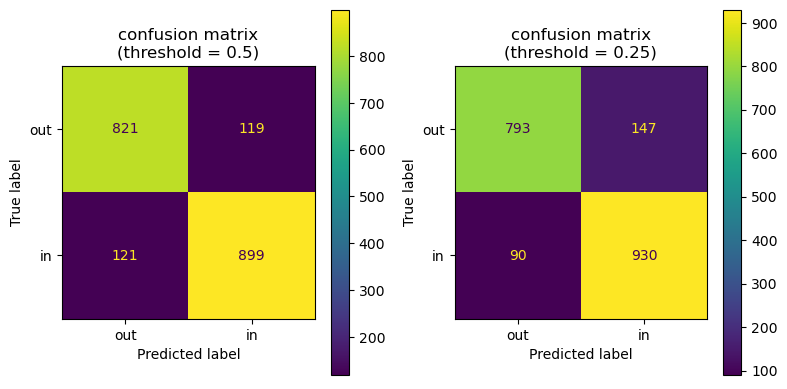

In [54]:
lr_preds_05 = (lr_probs >= 0.5).astype(int)  # binary at default threshold
lr_preds_025 = (lr_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

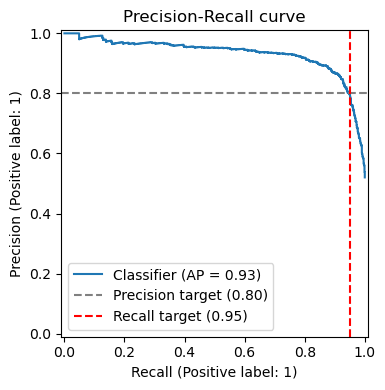

In [55]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, lr_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

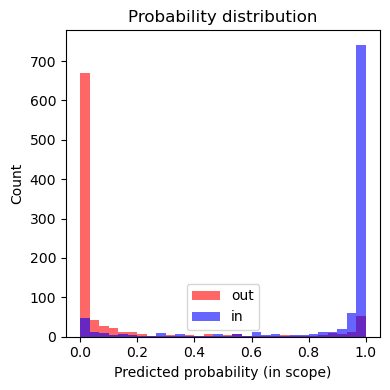

In [56]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

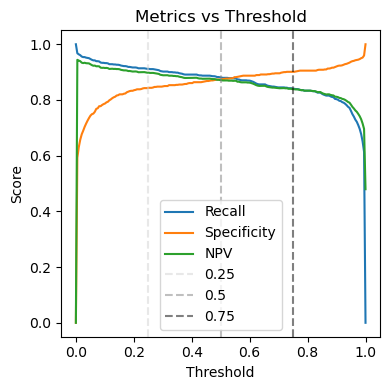

In [ ]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (lr_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('LR_threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [58]:
# Test data
lr_test_pred = clf.predict(X_test)
lr_test_proba = clf.predict_proba(X_test)[:, 1]

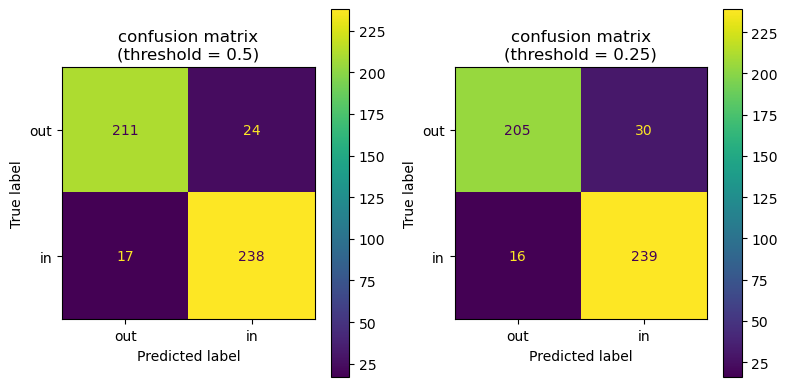

In [60]:
lr_test_preds_05 = (lr_test_proba >= 0.5).astype(int)  # binary at default threshold
lr_test_preds_025 = (lr_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

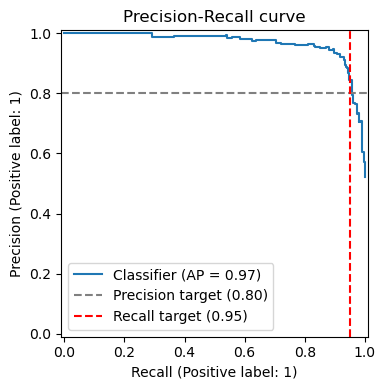

In [ ]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, lr_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

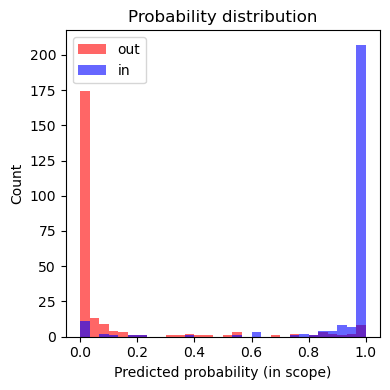

In [62]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

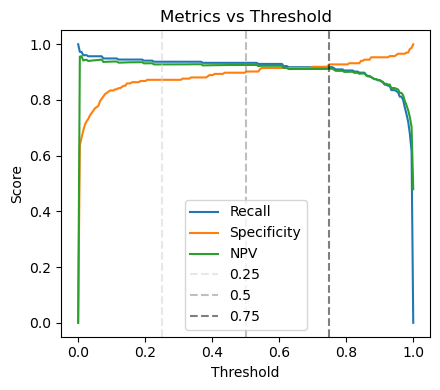

In [63]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (lr_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [224]:
# Metrics for threshold T
T = 0.1
pred = (lr_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.1, we remove 42.65% of all entries and loose ~2.65% of in scope cases.
Sensitivity: 0.9490196078431372, Specificity: 0.8340425531914893, NPV: 0.937799043062201


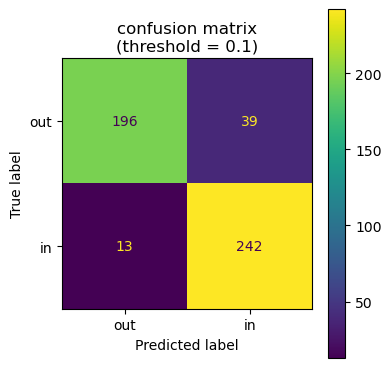

In [225]:
lr_test_preds_T = (lr_test_proba >= T).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_T),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title(f'confusion matrix\n(threshold = {T})')

plt.tight_layout()
plt.savefig(f'Plots/PatentSBERTa_LR_T{T}_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [79]:
# Combine tables with probabilities and predictions for threshold T
T = 0.1

d_train = y_train.copy()
d_train['proba'] = lr_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = lr_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

#### Manual check of false negative cases

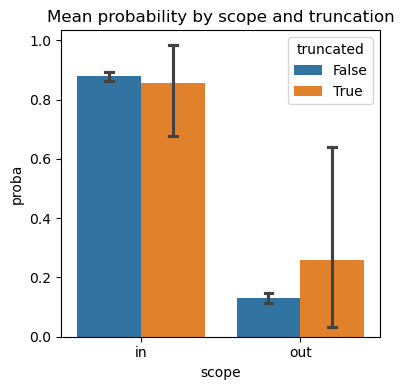

In [70]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig(f'Plots/PatentSBERTa_LR_T{T}_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

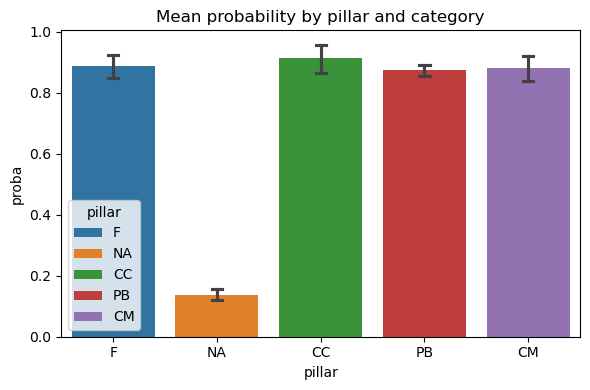

In [80]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
lr_false = d[((d['scope']=='in')  & (d['pred_0.1']==0)) | ((d['scope']=='out')  & (d['pred_0.1']==1))]
lr_false['truncated'].value_counts()

truncated
False    318
True       3
Name: count, dtype: int64

In [87]:
lr_fn = d[(d['scope']=='in')  & (d['pred_0.1']==0)]


### SVC

#### Cross validation

In [88]:
# SVC
svc = CalibratedClassifierCV(SVC(max_iter=1000, class_weight='balanced', C=100, kernel='rbf', gamma=0.01, random_state=42))
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [89]:
# fit model
svc.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
results_svc = cross_validate(svc, X_train, y_train_scope, cv=cv, scoring=scoring)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

In [90]:
# save trained model
joblib.dump(svc, 'Models/SVC_scope.joblib')

['Models/SVC_scope.joblib']

In [91]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = results_svc[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.920 ± 0.009
recall      : 0.935 ± 0.005
specificity : 0.912 ± 0.011
npv         : 0.929 ± 0.005
f1          : 0.928 ± 0.005


In [92]:
# Get prediction (out of fold)
svc_probs = cross_val_predict(svc, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
svc_preds = (svc_probs >= 0.5).astype(int)  # binary at default threshold

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

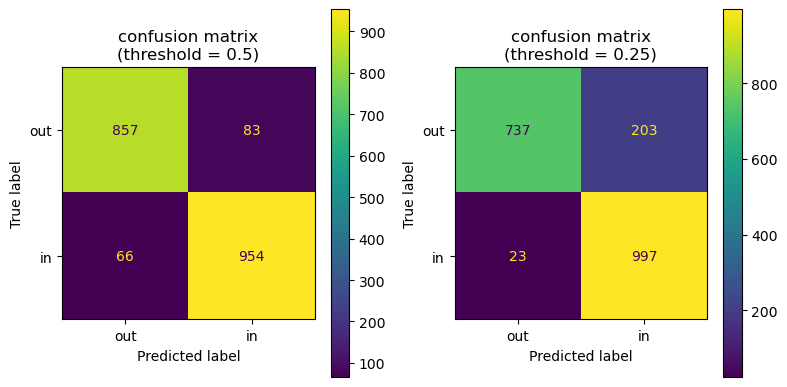

In [93]:
svc_preds_05 = (svc_probs >= 0.5).astype(int)  # binary at default threshold
svc_preds_025 = (svc_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

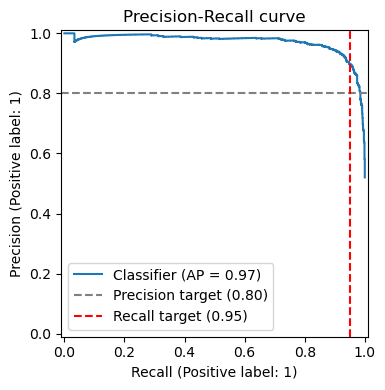

In [94]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, svc_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

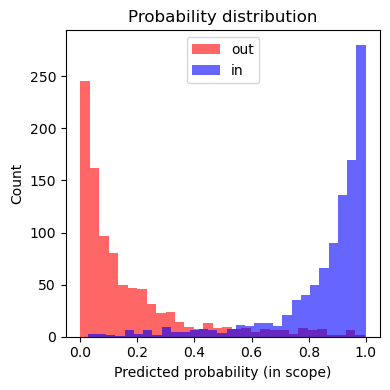

In [95]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

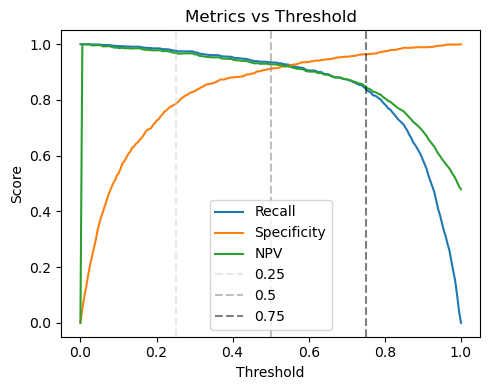

In [96]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (svc_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [97]:
# Test data
svc_test_pred = svc.predict(X_test)
svc_test_proba = svc.predict_proba(X_test)[:, 1]

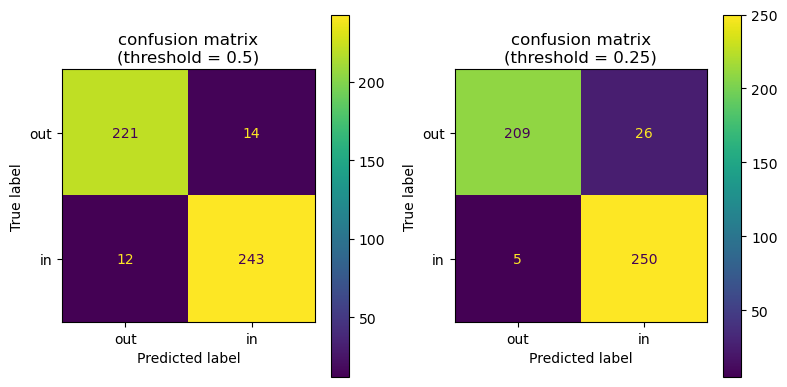

In [98]:
svc_test_preds_05 = (svc_test_proba >= 0.5).astype(int)  # binary at default threshold
svc_test_preds_025 = (svc_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

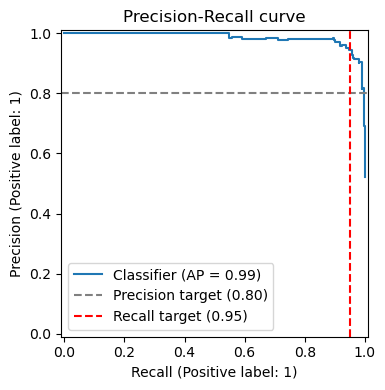

In [99]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, svc_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

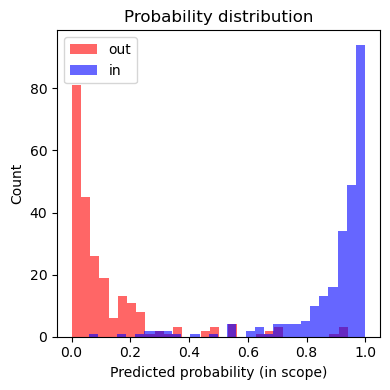

In [100]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

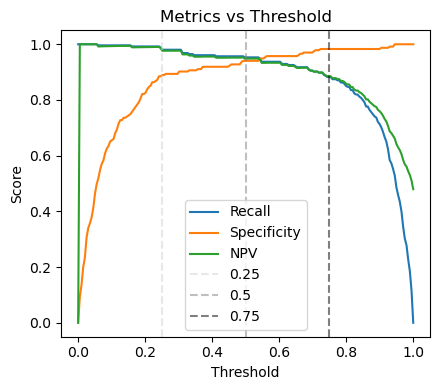

In [101]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (svc_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [226]:
# Metrics for threshold T
T = 0.2
pred = (svc_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.2, we remove 39.8% of all entries and loose ~0.41% of in scope cases.
Sensitivity: 0.9921568627450981, Specificity: 0.8212765957446808, NPV: 0.9897435897435898


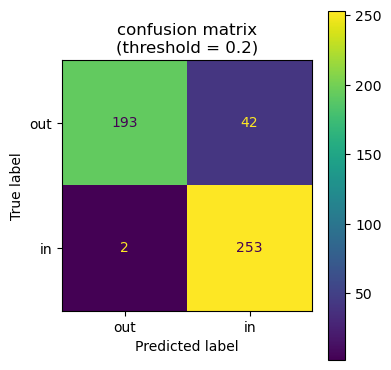

In [111]:
svc_test_preds_T = (svc_test_proba >= T).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_T),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title(f'confusion matrix\n(threshold = {T})')

plt.tight_layout()
plt.savefig(f'Plots/PatentSBERTa_SVC_T{T}_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

#### Manual check of false negative cases

In [112]:
# Combine tables with probabilities and predictions for threshold T
T = 0.2

d_train = y_train.copy()
d_train['proba'] = svc_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = svc_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

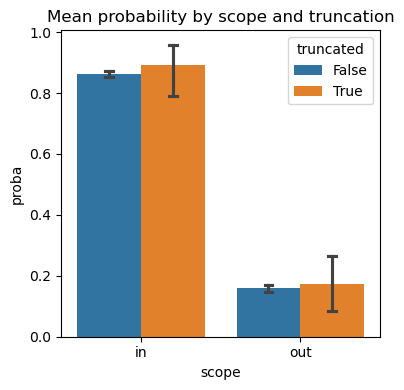

In [113]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

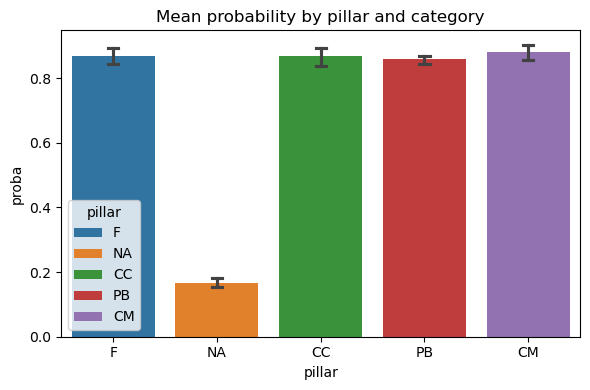

In [114]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [116]:
svc_fn = d[(d['scope']=='in')  & (d['pred_0.2']==0)]

### MLP

#### Cross validation

In [117]:
# MLP
mlp = MLPClassifier(max_iter=1000, early_stopping=True, hidden_layer_sizes=(256,128), learning_rate_init=0.001, alpha=0.0004, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [118]:
# fit model
mlp.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
mlp_results = cross_validate(mlp, X_train, y_train_scope, cv=cv, scoring=scoring)

In [119]:
# save trained model
joblib.dump(mlp, 'Models/MLP_scope.joblib')

['Models/MLP_scope.joblib']

In [120]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = mlp_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.896 ± 0.026
recall      : 0.918 ± 0.020
specificity : 0.883 ± 0.034
npv         : 0.909 ± 0.018
f1          : 0.906 ± 0.009


In [121]:
# Get prediction (out of fold)
mlp_probs = cross_val_predict(mlp, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
mlp_preds = (mlp_probs >= 0.5).astype(int)  # binary at default threshold


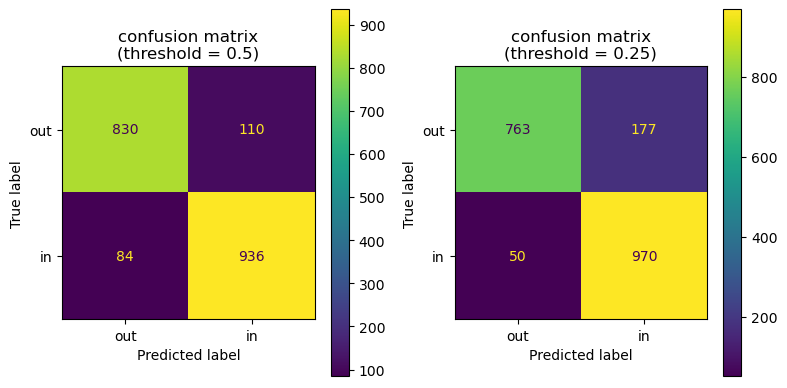

In [122]:
mlp_preds_05 = (mlp_probs >= 0.5).astype(int)  # binary at default threshold
mlp_preds_025 = (mlp_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

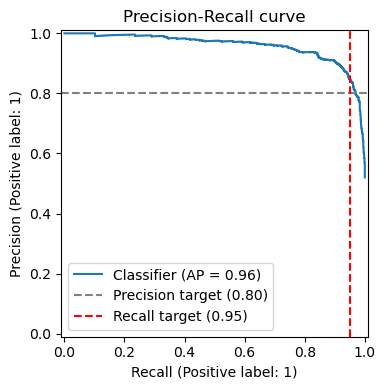

In [123]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, mlp_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

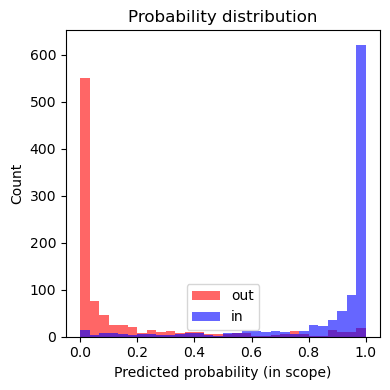

In [124]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

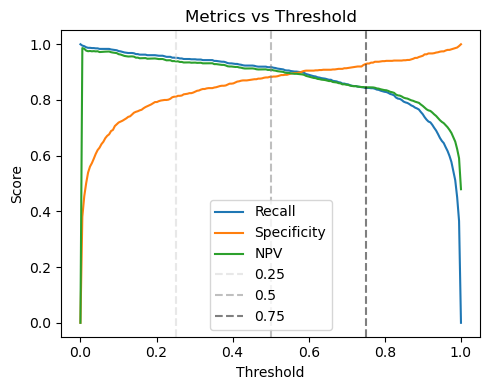

In [125]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (mlp_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [126]:
# Test data
mlp_test_pred = mlp.predict(X_test)
mlp_test_proba = mlp.predict_proba(X_test)[:, 1]

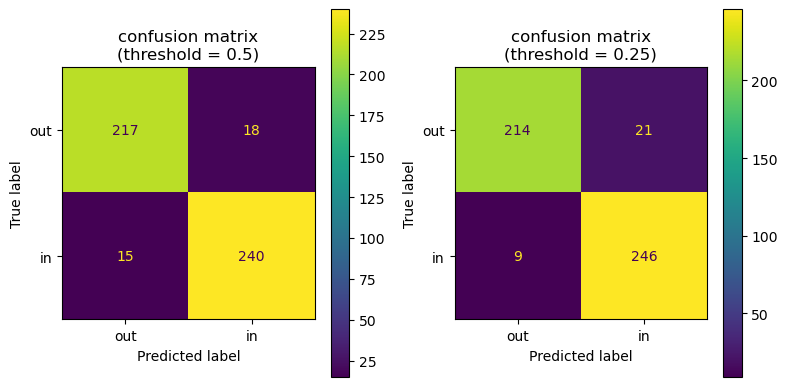

In [127]:
mlp_test_preds_05 = (mlp_test_proba >= 0.5).astype(int)  # binary at default threshold
mlp_test_preds_025 = (mlp_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

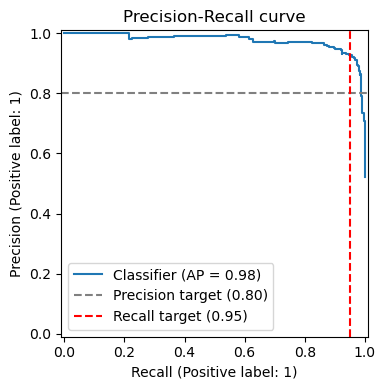

In [128]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, mlp_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

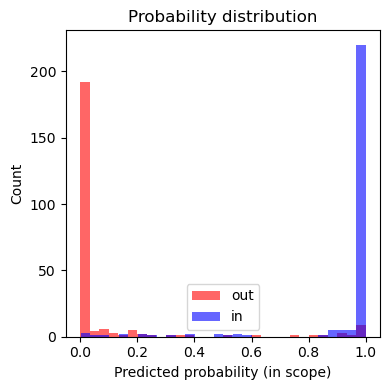

In [129]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

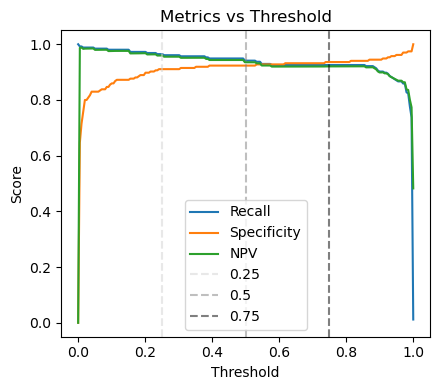

In [130]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (mlp_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [217]:
# Metrics for threshold T
T = 0.1
pred = (mlp_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.1, we remove 42.24% of all entries and loose ~1.02% of in scope cases.
Sensitivity: 0.9803921568627451, Specificity: 0.8595744680851064, NPV: 0.9758454106280193


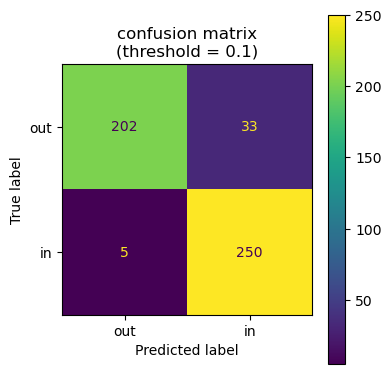

In [218]:
mlp_test_preds_T = (mlp_test_proba >= T).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_T),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title(f'confusion matrix\n(threshold = {T})')

plt.tight_layout()
plt.savefig(f'Plots/PatentSBERTa_MLP_T{T}_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

#### Manual check of borderline cases

In [219]:
# Combine tables with probabilities and predictions for threshold T
T = 0.1

d_train = y_train.copy()
d_train['proba'] = mlp_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = mlp_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

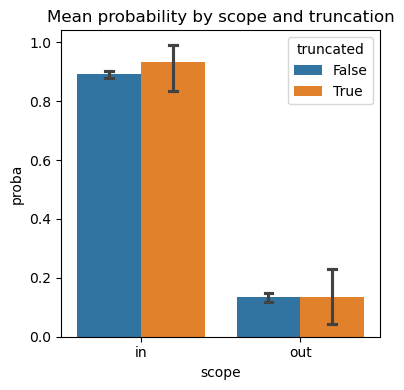

In [137]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

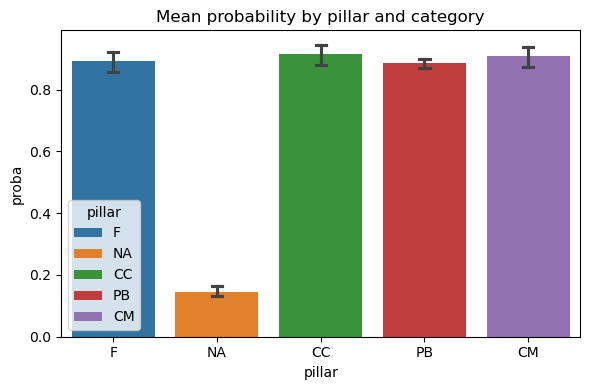

In [138]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [221]:
mlp_fn = d[(d['scope']=='in')  & (d['pred_0.1']==0)]

### False Negatives across models

In [222]:
fn = pd.concat([lr_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                svc_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                mlp_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']]])

fn = fn.drop_duplicates(subset='id')

fn['LR'] = fn['id'].isin(lr_fn['id'])
fn['SVC'] = fn['id'].isin(svc_fn['id'])
fn['MLP'] = fn['id'].isin(mlp_fn['id'])

fn.to_csv('PatentSBERTa_FalseNegatives.csv')

In [223]:
fn.value_counts(['LR', 'SVC', 'MLP'])

LR     SVC    MLP  
True   False  False    57
       True   True     12
       False  True      9
False  False  True      8
True   True   False     4
False  True   True      1
Name: count, dtype: int64

## AP Pillar

In [158]:
# Prepare pillar labels (mark NA's as 'None')
y_train_pillar = y_train['pillar'].fillna('NA')
y_test_pillar  = y_test['pillar'].fillna('NA')

pillar_classes = y_train_pillar.unique()

In [159]:
# Prepare training
## cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring for multiclass
scoring_pillar = {
    'precision': 'precision_macro',
    'recall':    'recall_macro',
    'f1':        'f1_macro'
}

### Logistic Regression

In [160]:
# Find best LR model
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs', 'liblinear', 'newton-cholesky']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                    param_grid, cv=cv, scoring=scoring_pillar, refit='recall', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'C': 100, 'solver': 'lbfgs'}


In [161]:
lr_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_C', 'param_solver', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1']
lr_grid[cols].sort_values('mean_test_recall', ascending=False)

,param_C,param_solver,mean_test_precision,mean_test_recall,mean_test_f1
9,100.0,lbfgs,0.877312,0.877472,0.877376
11,100.0,newton-cholesky,0.877312,0.877472,0.877376
10,100.0,liblinear,0.877421,0.877388,0.877347
13,1000.0,liblinear,0.876420,0.876575,0.876367
6,10.0,lbfgs,0.872215,0.872445,0.872282
7,10.0,liblinear,0.872200,0.872445,0.872284
8,10.0,newton-cholesky,0.872270,0.872320,0.872249
12,1000.0,lbfgs,0.870238,0.870192,0.870186
14,1000.0,newton-cholesky,0.870238,0.870192,0.870186
4,1.0,liblinear,0.863420,0.862954,0.862980


In [162]:
# Logistic Regression
clf_pillar = LogisticRegression(
    C=100,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42 
)

In [163]:
# Cross-validation
lr_results_pillar = cross_validate(clf_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
lr_results_pillar

{'fit_time': array([0.27482891, 0.32909489, 0.25539994, 0.30230618, 0.23729634]),
 'score_time': array([0.03126645, 0.02010918, 0.02312493, 0.02184081, 0.02408361]),
 'test_precision': array([0.69831436, 0.75164912, 0.76246177, 0.85697816, 0.82000292]),
 'test_recall': array([0.72171838, 0.77294314, 0.78009245, 0.79745507, 0.80776639]),
 'test_f1': array([0.70391639, 0.76000696, 0.76654916, 0.82156091, 0.80978233])}

In [164]:
# Fit model
clf_pillar.fit(X_train, y_train_pillar)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [165]:
# save trained model
joblib.dump(clf_pillar, 'Models/LR_pillar.joblib')

['Models/LR_pillar.joblib']

In [166]:
# Predict training (cross validation)
lr_pred_pillar = cross_val_predict(clf_pillar, X_train, y_train_pillar)
lr_proba_pillar = cross_val_predict(clf_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]


In [167]:
# Predict test dataset
lr_pillar_test_pred = clf_pillar.predict(X_test)
lr_pillar_test_proba = clf_pillar.predict_proba(X_test)[:, 1]

In [168]:
print(pd.Series(y_test_pillar).dtype)
print(pd.Series(y_test_pillar).isna().sum())

str
0


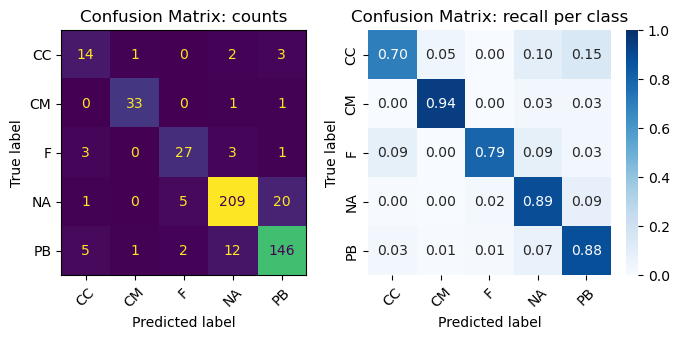

In [169]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, lr_pillar_test_pred,
    display_labels=clf_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, lr_pillar_test_pred, labels=clf_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=clf_pillar.classes_,
    yticklabels=clf_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [230]:
# Combine tables with probabilities and predictions for threshold T
T = 0.1

d_train = y_train.copy()
d_train['proba_scope'] = lr_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = lr_proba_pillar
d_train['pred_pillar'] = lr_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = lr_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = lr_pillar_test_proba
d_test['pred_pillar'] = lr_pillar_test_pred

d_train['set'] = "train"
d_test['set'] = "test"

d_lr = pd.concat([d_train, d_test])
d_lr['Threshold_scope'] = T

Text(0.5, 1.0, 'Confusion Matrix')

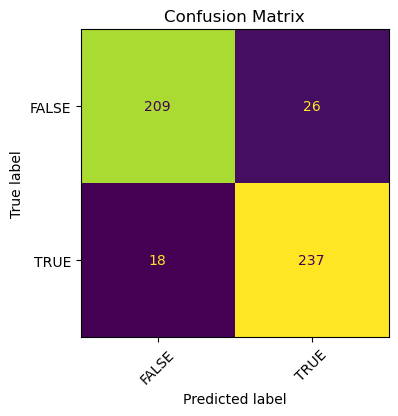

In [172]:
# Confusion matrix pillar vs. no pillar
fig, axes = plt.subplots(figsize=(4,4))

pillar_overall = (y_test_pillar != 'NA').astype(int)
pillar_pred_overall = (lr_pillar_test_pred != 'NA').astype(int)

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    pillar_overall, pillar_pred_overall,
    display_labels=['FALSE', 'TRUE'],
    ax=axes,
    colorbar=False,
    xticks_rotation=45
)
axes.set_title('Confusion Matrix')

### SVC

In [173]:
# Test hyperparameters of Support Vector Classification model
param_grid = {
    'estimator__C':     [1, 10, 100, 1000],
    'estimator__gamma': [0.001, 0.01],
    'estimator__kernel': ['linear', 'rbf']
}

# CalibratedClasssifierCV wrapper to get calibrated probabilities
calibrated_svc = CalibratedClassifierCV(
    SVC(class_weight='balanced'),
    cv=cv,
    ensemble=False
)

grid = GridSearchCV(calibrated_svc, param_grid, cv=cv, scoring=scoring_pillar, refit='f1', n_jobs=-1)
grid.fit(X_train, y_train_pillar)
print(grid.best_params_)

{'estimator__C': 1000, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}


In [175]:
# save results to data frame
svc_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1']
svc_grid[cols].sort_values('mean_test_f1', ascending=False)

,param_estimator__C,param_estimator__gamma,param_estimator__kernel,mean_test_precision,mean_test_recall,mean_test_f1
15,1000,0.010,rbf,0.856648,0.815603,0.831586
11,100,0.010,rbf,0.856708,0.815518,0.831571
7,10,0.010,rbf,0.848708,0.816701,0.829752
13,1000,0.001,rbf,0.824040,0.813342,0.815550
6,10,0.010,linear,0.803456,0.781626,0.789009
4,10,0.001,linear,0.803456,0.781626,0.789009
2,1,0.010,linear,0.800626,0.780811,0.787426
0,1,0.001,linear,0.800626,0.780811,0.787426
12,1000,0.001,linear,0.801370,0.779008,0.785981
10,100,0.010,linear,0.801370,0.779008,0.785981


In [176]:
# SVC
svc_pillar = CalibratedClassifierCV(
    SVC(max_iter=1000, 
        class_weight='balanced', 
        C=1000, kernel='rbf',
        gamma=0.01, 
        random_state=42))

In [ ]:
# Cross-validation
svc_results_pillar = cross_validate(svc_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
svc_results_pillar

In [ ]:
# Fit model
svc_pillar = svc_pillar.fit(X_train, y_train_pillar)

In [179]:
# save trained model
joblib.dump(svc_pillar, 'Models/SVC_pillar.joblib')

['Models/SVC_pillar.joblib']

In [ ]:
# Get training predictions
# Predict training (cross validation)
svc_pred_pillar = cross_val_predict(svc_pillar, X_train, y_train_pillar)
svc_proba_pillar = cross_val_predict(svc_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]

In [181]:
# Get test data predictions
svc_pillar_test_pred = svc_pillar.predict(X_test)
svc_pillar_test_proba = svc_pillar.predict_proba(X_test)[:, 1]

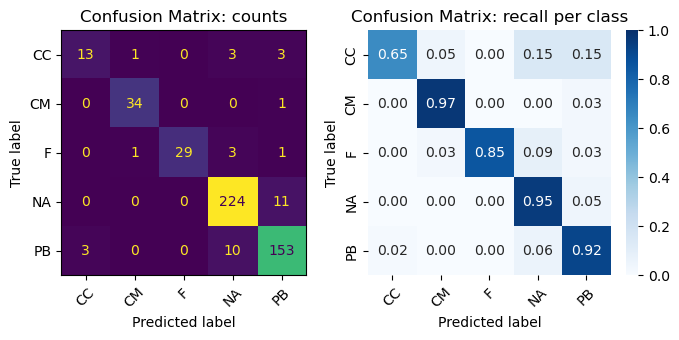

In [182]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, svc_pillar_test_pred,
    display_labels=svc_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, svc_pillar_test_pred, labels=svc_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=svc_pillar.classes_,
    yticklabels=svc_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [229]:
# Combine tables with probabilities and predictions for threshold T
T = 0.2

d_train = y_train.copy()
d_train['proba_scope'] = svc_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = svc_proba_pillar
d_train['pred_pillar'] = svc_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = svc_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = svc_pillar_test_proba
d_test['pred_pillar'] = svc_pillar_test_pred

d_train['set'] = "train"
d_test['set'] = "test"

d_svc = pd.concat([d_train, d_test])
d_svc['Threshold_scope'] = T

### MLP

In [184]:
# Test hyperparameters of Multi-Layer Perceptron model
param_dist = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01],
    'learning_rate_init': [0.00001, 0.0001, 0.001, 0.01],
    'solver': ['lbfgs', 'adam']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, random_state=42, max_iter=1000),
    param_distributions=param_dist,
    n_iter=100,
    scoring=scoring_pillar,
    refit='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

grid.fit(X_train, y_train_pillar)
print(grid.best_params_)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 96 is smaller than n_iter=100. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'solver': 'lbfgs', 'learning_rate_init': 1e-05, 'hidden_layer_sizes': (64, 32), 'alpha': 0.01}


In [185]:
# save results to data frame
mlp_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 'param_alpha', 'param_solver',
        'mean_test_precision', 'mean_test_recall',  'mean_test_f1']

mlp_grid[cols].sort_values('mean_test_f1', ascending=False)


,param_hidden_layer_sizes,param_learning_rate_init,param_alpha,param_solver,mean_test_precision,mean_test_recall,mean_test_f1
21,"(256, 128)",0.00100,0.00001,adam,0.820998,0.795323,0.804189
78,"(64, 32)",0.01000,0.01000,lbfgs,0.804409,0.797650,0.799147
74,"(64, 32)",0.00010,0.01000,lbfgs,0.804409,0.797650,0.799147
72,"(64, 32)",0.00001,0.01000,lbfgs,0.804409,0.797650,0.799147
76,"(64, 32)",0.00100,0.01000,lbfgs,0.804409,0.797650,0.799147
...,...,...,...,...,...,...,...
33,"(128, 64)",0.00001,0.00010,adam,0.266375,0.223615,0.170908
25,"(64, 32)",0.00001,0.00010,adam,0.094531,0.235000,0.097104
1,"(64, 32)",0.00001,0.00001,adam,0.094531,0.235000,0.097104
49,"(64, 32)",0.00001,0.00100,adam,0.094531,0.235000,0.097104


In [186]:
# MLP
mlp_pillar = MLPClassifier(
    max_iter=1000, 
    early_stopping=True, 
    hidden_layer_sizes=(256,128), 
    solver='adam',
    learning_rate_init=0.001, 
    alpha=0.00001, 
    random_state=42)

In [187]:
# Cross-validation
mlp_results_pillar = cross_validate(mlp_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
mlp_results_pillar

{'fit_time': array([1.63459373, 2.03777885, 1.71589637, 2.66020966, 2.06497717]),
 'score_time': array([0.01826549, 0.02058172, 0.01596212, 0.02395582, 0.02120781]),
 'test_precision': array([0.75328239, 0.81802352, 0.81629073, 0.92238342, 0.79500995]),
 'test_recall': array([0.72657619, 0.81497242, 0.79046993, 0.82724031, 0.81735685]),
 'test_f1': array([0.73627127, 0.81496417, 0.80209117, 0.86540022, 0.80221926])}

In [188]:
# Fit model
mlp_pillar = mlp_pillar.fit(X_train, y_train_pillar)

In [189]:
# save trained model
joblib.dump(mlp_pillar, 'Models/MLP_pillar.joblib')

['Models/MLP_pillar.joblib']

In [190]:
# Get training predictions
# Predict training (cross validation)
mlp_pred_pillar = cross_val_predict(mlp_pillar, X_train, y_train_pillar)
mlp_proba_pillar = cross_val_predict(mlp_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]

In [191]:
# Get test data predictions
mlp_pillar_test_pred = mlp_pillar.predict(X_test)
mlp_pillar_test_proba = mlp_pillar.predict_proba(X_test)[:, 1]

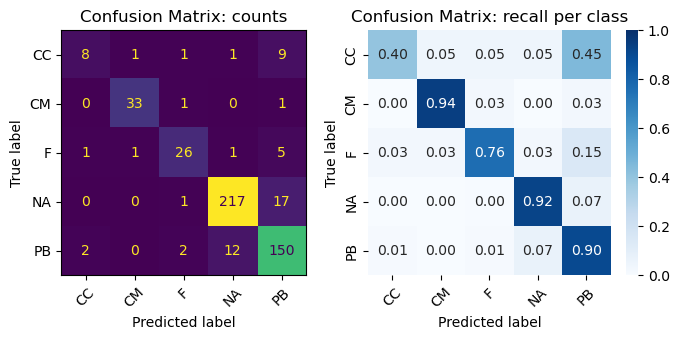

In [192]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, mlp_pillar_test_pred,
    display_labels=mlp_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, mlp_pillar_test_pred, labels=mlp_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=mlp_pillar.classes_,
    yticklabels=mlp_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [228]:
# Combine tables with probabilities and predictions for threshold T
T = 0.01

d_train = y_train.copy()
d_train['proba_scope'] = mlp_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = mlp_proba_pillar
d_train['pred_pillar'] = mlp_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = mlp_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = mlp_pillar_test_proba
d_test['pred_pillar'] = mlp_pillar_test_pred

d_train['set'] = "train"
d_test['set'] = "test"

d_mlp = pd.concat([d_train, d_test])
d_mlp['Threshold_scope'] = T

## Comparison

### Plot threshold vs. exclusion

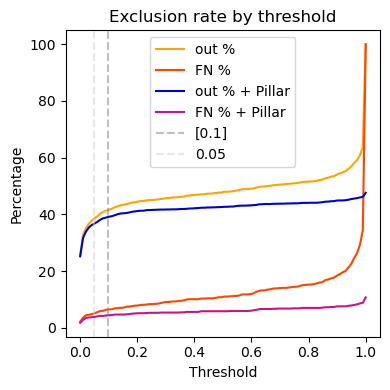

In [196]:
# LR
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_lr.copy()
T = d_lr['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='grey', linestyle='--', alpha=0.5, label=T)
#ax.axvline(0.1, color='lightgrey', linestyle='--', alpha=0.5, label='0.1')
ax.axvline(0.05, color='lightgrey', linestyle='--', alpha=0.5, label=0.05)

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_LR_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

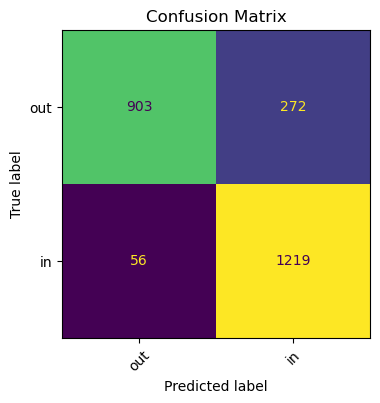

In [234]:
## Combined confusion matrix
T = 0.10

d_lr['pred_scope'] = (d_lr['proba_scope'] >= T).astype(int)
d_lr['Threshold_scope'] = T
d_lr['pred_combined'] = ((d_lr['pred_pillar'] != 'NA') | d_lr['pred_scope'] == 1).astype(int)

# Confusion matrix pillar vs. no pillar
fig, axes = plt.subplots(figsize=(4,4))

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    (d_lr['scope'] == 'in').astype(int), d_lr['pred_combined'],
    display_labels=['out', 'in'],
    ax=axes,
    colorbar=False,
    xticks_rotation=45
)
axes.set_title('Confusion Matrix')

In [244]:
## Results scope only
p, c = np.unique(d_lr['pred_scope'], return_counts=True)
FN = len(d_lr[(d_lr['scope'] == 'in') & (d_lr['pred_scope'] == 0)])

print(f"Scope only: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_lr) * 100,2)}% of in scope cases.")

Scope only: With a threshold of 0.2, we remove 41.55% of all entries and loose ~3.35% of in scope cases.


In [245]:
## Results with pillar combined
p, c = np.unique(d_lr['pred_combined'], return_counts=True)
FN = len(d_lr[(d_lr['scope'] == 'in') & (d_lr['pred_combined'] == 0)])

print(f"Scope + Pillar: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_lr) * 100,2)}% of in scope cases.")

Scope + Pillar: With a threshold of 0.2, we remove 39.14% of all entries and loose ~2.29% of in scope cases.


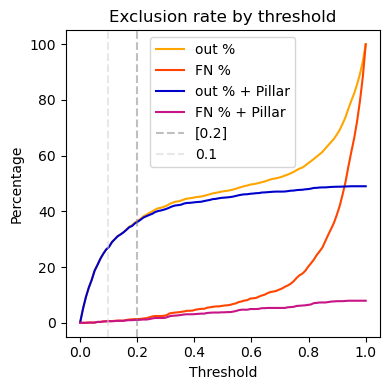

In [202]:
# SVC
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_svc.copy()
T = d_svc['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='grey', linestyle='--', alpha=0.5, label=T)
ax.axvline(0.1, color='lightgrey', linestyle='--', alpha=0.5, label=0.1)

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_SVC_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

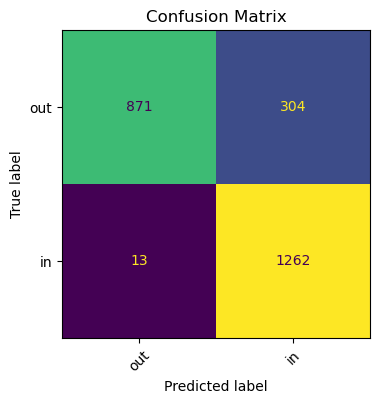

In [237]:
## Combined confusion matrix
T = 0.2

d_svc['pred_scope'] = (d_svc['proba_scope'] >= T).astype(int)
d_svc['Threshold_scope'] = T
d_svc['pred_combined'] = ((d_svc['pred_pillar'] != 'NA') | d_svc['pred_scope'] == 1).astype(int)

# Confusion matrix pillar vs. no pillar
fig, axes = plt.subplots(figsize=(4,4))

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    (d_svc['scope'] == 'in').astype(int), d_svc['pred_combined'],
    display_labels=['out', 'in'],
    ax=axes,
    colorbar=False,
    xticks_rotation=45
)
axes.set_title('Confusion Matrix')

In [242]:
## Results scope only
p, c = np.unique(d_svc['pred_scope'], return_counts=True)
FN = len(d_svc[(d_svc['scope'] == 'in') & (d_svc['pred_scope'] == 0)])

print(f"Scope only: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_svc) * 100,2)}% of in scope cases.")

Scope only: With a threshold of 0.2, we remove 36.37% of all entries and loose ~0.69% of in scope cases.


In [243]:
## Results with pillar combined
p, c = np.unique(d_svc['pred_combined'], return_counts=True)
FN = len(d_svc[(d_svc['scope'] == 'in') & (d_svc['pred_combined'] == 0)])

print(f"Scope + Pillar: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_svc) * 100,2)}% of in scope cases.")

Scope + Pillar: With a threshold of 0.2, we remove 36.08% of all entries and loose ~0.53% of in scope cases.


In [240]:
d_svc[(d_svc['scope'] == "in") & (d_svc['pred_scope'] == 0)]

,id,family_id,application_number,title,abstract,cpc,publication_year,jurisdiction,scope,pillar,...,text,embedding,stratify_label,proba_scope,pred_scope,proba_pillar,pred_pillar,set,Threshold_scope,pred_combined
1862,WO-2025181349-A1,90123096,EP2025/055554,FOOD COMPRISING FISH MYOGLOBIN,The present invention relates to a fish or mea...,"['A23K20/147', 'C12N1/14', 'C12N1/16', 'C12N1/...",2025,WO,in,F,...,FOOD COMPRISING FISH MYOGLOBIN [SEP] The prese...,"[0.059838306, -0.4187508, -0.11913725, -0.2120...",inF,0.085592,0,0.001683,NA,train,0.2,0
1213,EP-4658080-A1,85158770,EP24703084.4,RUBISCO IN CAKE,"The invention relates to a dough, batter or in...","['C12Y401/01039', 'A23L15/35', 'A21D13/064', '...",2025,EP,in,PB,...,RUBISCO IN CAKE [SEP] The invention relates to...,"[0.16174975, -0.9188766, -0.119583875, -0.1010...",inPB,0.058175,0,0.001512,NA,train,0.2,0
2335,WO-2025071427-A1,95201513,RS2023/000015,APPARATUS WITH INTEGRATED ELECTRODES FOR ELECT...,"The invention is a device, shown in Fig 1., co...","['B01L3/5085', 'B01L2300/0858', 'B01L2300/0887...",2025,WO,in,CM,...,APPARATUS WITH INTEGRATED ELECTRODES FOR ELECT...,"[-0.08710785, -0.83745706, -0.2562955, -0.0305...",inCM,0.166179,0,0.794872,CM,train,0.2,1
1532,EP-4516112-A1,88017832,EP23306453.4,METHOD FOR PROCESSING SUGAR BEET BY-PRODUCT,The invention describes a method for processin...,"['A23K10/12', 'A61K2236/11', 'A23K10/30', 'A61...",2025,EP,in,PB,...,METHOD FOR PROCESSING SUGAR BEET BY-PRODUCT [S...,"[0.2927859, -0.55651003, -0.1499208, -0.089488...",inPB,0.113531,0,0.003641,NA,train,0.2,0
1347,EP-4518685-A1,86330082,EP23722268.2,METHOD OF PREVENTING AND/OR INHIBITING THE OUT...,The present invention is related to a method o...,"['A23B2/754', 'A23B4/20', 'A23B4/12', 'A23B2/7...",2025,EP,in,PB,...,METHOD OF PREVENTING AND/OR INHIBITING THE OUT...,"[0.030002445, -1.1324558, -0.08397737, -0.1433...",inPB,0.080013,0,0.010361,NA,train,0.2,0
1540,JP-2026514896-A,88068434,JP2025561375,Method for preparing a stable emulsion by magn...,The present invention relates to a method for ...,"['B01F23/43', 'B01F23/411', 'B01F2025/916', 'A...",2026,JP,in,PB,...,Method for preparing a stable emulsion by magn...,"[0.23305573, -0.9037766, -0.10349006, -0.31603...",inPB,0.127871,0,0.002495,NA,train,0.2,0
1218,US-20250099925-A1,85175953,US18833109,CAPSULES WITH SOLIDIFIED MATRIX,Disclosed herein is a method for generating ca...,"['A61K8/0283', 'B01F25/4522', 'B01F23/4145', '...",2025,US,in,PB,...,CAPSULES WITH SOLIDIFIED MATRIX [SEP] Disclose...,"[0.383405, -0.6801446, -0.016049257, -0.108496...",inPB,0.178891,0,0.151007,PB,train,0.2,1
2200,WO-2025201667-A1,92932939,EP2024/077488,METHOD AND SYSTEM FOR RECYCLING AND LIBERATING...,A versatile waste processing system that conve...,"['C10K3/023', 'Y02E50/10', 'C10B53/00', 'C10K1...",2025,WO,in,PB,...,METHOD AND SYSTEM FOR RECYCLING AND LIBERATING...,"[0.23309733, -0.40457597, -0.21609133, 0.22085...",inPB,0.026561,0,0.009912,NA,train,0.2,0
1167,US-20250040583-A1,84901556,US18718209,ENCAPSULATED METAL COMPOUNDS AND COMESTIBLE US...,The present disclosure relates generally to th...,"['A23L33/16', 'A23K50/40', 'A23K20/30', 'A23L3...",2025,US,in,PB,...,ENCAPSULATED METAL COMPOUNDS AND COMESTIBLE US...,"[0.0651023, -0.76050967, -0.20416869, -0.00793...",inPB,0.165370,0,0.002194,NA,train,0.2,0
1488,WO-2025045826-A1,87845506,EP2024/073830,COMPOUNDS FOR ACTIVATION OF FGFR1 SIGNALING,The present invention relates to compound of f...,"['C12N2501/999', 'C07C2602/38', 'C07C2601/04',...",2025,WO,in,CM,...,COMPOUNDS FOR ACTIVATION OF FGFR1 SIGNALING [S...,"[0.10020002, -0.82614815, -0.082205094, -0.131...",inCM,0.097263,0,0.783379,CM,train,0.2,1


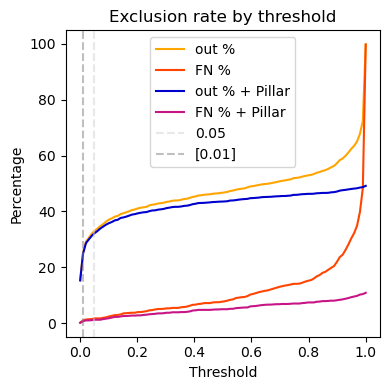

In [207]:
# MLP
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_mlp.copy()
T = d_mlp['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(0.05, color='lightgrey', linestyle='--', alpha=0.5, label=0.05)
ax.axvline(T, color='grey', linestyle='--', alpha=0.5, label=T)

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

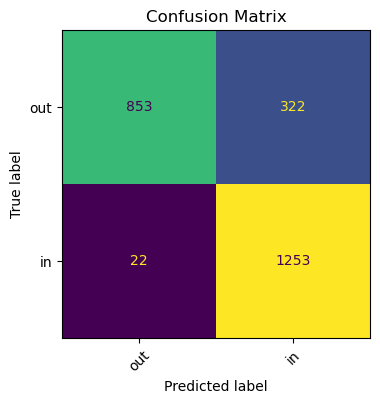

In [248]:
## Combined confusion matrix
T = 0.1

d_mlp['pred_scope'] = (d_mlp['proba_scope'] >= T).astype(int)
d_mlp['Threshold_scope'] = T
d_mlp['pred_combined'] = ((d_mlp['pred_pillar'] != 'NA') | d_mlp['pred_scope'] == 1).astype(int)

# Confusion matrix pillar vs. no pillar
fig, axes = plt.subplots(figsize=(4,4))

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    (d_mlp['scope'] == 'in').astype(int), d_mlp['pred_combined'],
    display_labels=['out', 'in'],
    ax=axes,
    colorbar=False,
    xticks_rotation=45
)
axes.set_title('Confusion Matrix')

In [250]:
## Results scope only
p, c = np.unique(d_mlp['pred_scope'], return_counts=True)
FN = len(d_mlp[(d_mlp['scope'] == 'in') & (d_mlp['pred_scope'] == 0)])

print(f"Scope only: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_mlp) * 100,2)}% of in scope cases.")

Scope only: With a threshold of 0.1, we remove 36.98% of all entries and loose ~1.22% of in scope cases.


In [249]:
## Results with pillar combined
p, c = np.unique(d_mlp['pred_combined'], return_counts=True)
FN = len(d_mlp[(d_mlp['scope'] == 'in') & (d_mlp['pred_combined'] == 0)])

print(f"Scope + Pillar: With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_mlp) * 100,2)}% of in scope cases.")

Scope + Pillar: With a threshold of 0.1, we remove 35.71% of all entries and loose ~0.9% of in scope cases.


#### Combine different classifiers

In [251]:
# Combine MLP in/out of scope classifier with SVC pillar classification
# Combine tables with probabilities and predictions for threshold T
T = 0.1

d_train = y_train.copy()
d_train['proba_scope'] = mlp_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = svc_proba_pillar
d_train['pred_pillar'] = svc_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = mlp_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = svc_pillar_test_proba
d_test['pred_pillar'] = svc_pillar_test_pred

d_comb = pd.concat([d_train, d_test])
d_comb['Threshold_scope'] = T

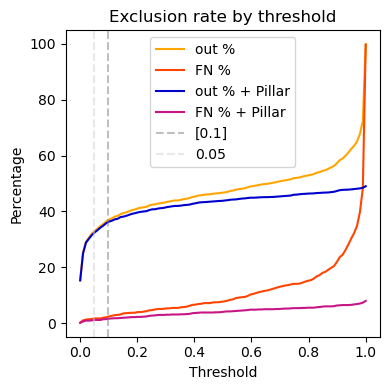

In [253]:
# MLP + LR
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_comb.copy()
T = d_comb['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='grey', linestyle='--', alpha=0.5, label=T)
ax.axvline(0.05, color='lightgrey', linestyle='--', alpha=0.5, label=0.05)


ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_SVC_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [254]:
T = 0.1
d_comb['pred_combined'] = ((d_comb['pred_pillar'] != 'NA') | (d_comb['proba_scope'] >= T)).astype(int)
p, c = np.unique(d_comb['pred_combined'], return_counts=True)
FN = len(d_comb[(d_comb['scope'] == 'in') & (d_comb['pred_combined'] == 0)])

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(d_comb) * 100,2)}% of in scope cases.")

With a threshold of 0.1, we remove 36.29% of all entries and loose ~0.82% of in scope cases.


In [255]:
## Build table to compare performance and thresholds across models
datasets = {'LR': d_lr, 'SVC': d_svc, 'MLP': d_mlp, 'MLP_SVC': d_comb}  # add more: 'rf': d_rf, etc.

df_comparison = pd.DataFrame(np.linspace(0, 0.5, 101), columns=['Threshold'])

for name, d_tmp in datasets.items():
    tmp = d_tmp.copy()
    results = []

    for T in np.linspace(0, 0.5, 101):
        tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | (tmp['proba_scope'] >= T)).astype(int)
        out = len(tmp[tmp['pred_combined'] == 0])
        fn = len(tmp[(tmp['scope'] == 'in') & (tmp['pred_combined'] == 0)])

        results.append([
            round(out / len(tmp) * 100, 2),
            round(fn / len(tmp) * 100, 2)
        ])

    df_comparison[[f'out_{name}', f'lost_{name}']] = results

In [256]:
df_comparison.to_csv('Threshold_comparison_models.csv')
df_comparison

,Threshold,out_LR,lost_LR,out_SVC,lost_SVC,out_MLP,lost_MLP,out_MLP_SVC,lost_MLP_SVC
0,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.005,29.80,1.35,2.82,0.00,20.98,0.20,20.98,0.20
2,0.010,31.47,1.43,4.86,0.00,24.29,0.24,24.41,0.24
3,0.015,32.73,1.59,6.82,0.00,26.57,0.41,26.65,0.37
4,0.020,33.88,1.80,8.65,0.00,28.45,0.49,28.61,0.45
...,...,...,...,...,...,...,...,...,...
96,0.480,42.49,3.02,44.53,1.92,43.47,2.53,43.71,2.00
97,0.485,42.53,3.02,44.61,1.92,43.47,2.53,43.71,2.00
98,0.490,42.57,3.02,44.82,1.96,43.51,2.57,43.76,2.04
99,0.495,42.57,3.02,44.86,1.96,43.51,2.57,43.76,2.04


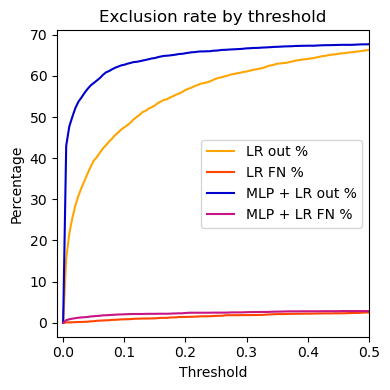

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

# all three metrics vs threshold
ax.plot(df_comparison['Threshold'], df_comparison['out_LR'], label='LR out %', color='orange')
ax.plot(df_comparison['Threshold'], df_comparison['lost_LR'], label='LR FN %', color='orangered')
ax.plot(df_comparison['Threshold'], df_comparison['out_MLP_LR'], label='MLP + LR out %', color='mediumblue')
ax.plot(df_comparison['Threshold'], df_comparison['lost_MLP_LR'], label='MLP + LR FN %', color='mediumvioletred')

#ax.axvline(T, color='lightgrey', linestyle='--', alpha=0.5, label='Threshold')
ax.set_xlim(-0.01, 0.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/PatentSBERTa_MLP_LR_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [453]:
d_lr

,id,title,abstract,year,scope,pillar,research_category,truncated,stratify_label,text,proba_scope,pred_scope,proba_pillar,pred_pillar,Threshold_scope,pred_combined
2427,pub.1185798411,Universal compression behaviour of semi-hard c...,"In this study, we explored the fracture and rh...",2025,in,PB,End product formulation,False,End product formulation,Universal compression behaviour of semi-hard c...,0.989406,1,5.909942e-02,PB,0.1,1
2811,pub.1191268970,Influence of Fermentation and Milling Processe...,The study aimed to evaluate how different prod...,2025,in,PB,End product formulation,False,End product formulation,Influence of Fermentation and Milling Processe...,0.502911,1,3.204721e-04,PB,0.1,1
4465,pub.1193014463,Combined Effects of Spirulina (Limnospira plat...,"Heat stress (HS) affects poultry growth, immun...",2025,out,NA,NA,False,NA-NA,Combined Effects of Spirulina (Limnospira plat...,0.001209,0,1.007384e-06,NA,0.1,0
3857,pub.1193533905,Teaching evidence-based medicine in medical ed...,BackgroundEvidence-based medicine (EBM) is an ...,2025,out,NA,NA,False,NA-NA,Teaching evidence-based medicine in medical ed...,0.000003,0,2.056521e-07,NA,0.1,0
2500,pub.1195792290,Montenegrin Sudžuk Fermented Sausage Uncovered...,This study characterizes Montenegrin artisanal...,2025,out,NA,NA,True,NA-NA,Montenegrin Sudžuk Fermented Sausage Uncovered...,0.235825,1,9.180669e-05,NA,0.1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,pub.1186481493,Ernährung bei chronischer Nierenerkrankung nac...,The recommendations on nutrition in chronic ki...,2025,out,NA,NA,False,NA-NA,Ernährung bei chronischer Nierenerkrankung nac...,0.023856,0,3.316915e-04,NA,0.1,0
3377,pub.1190646684,Unveiling the therapeutic potential of phenoli...,Osteoarthritis (OA) is a joint disease charact...,2025,out,NA,NA,False,NA-NA,Unveiling the therapeutic potential of phenoli...,0.081691,0,5.425456e-03,NA,0.1,0
3158,pub.1187991454,"Development, optimization and integrated chara...","Plant-based yogurt substitutes (""gurts""), whos...",2025,in,PB,End product formulation,False,End product formulation,"Development, optimization and integrated chara...",0.885531,1,2.072300e-02,PB,0.1,1
2878,pub.1189784599,Beta-glucan-enriched diets improve immune func...,Beta-glucans are bioactive polysaccharides wit...,2025,out,NA,NA,False,NA-NA,Beta-glucan-enriched diets improve immune func...,0.000294,0,4.042598e-04,NA,0.1,0


In [457]:
# Combine for output table
# Add probabilities (scope & pillar), predictions (scope & pillar), Threshold

data['proba_scope'] = d_lr['proba_scope']
data['pred_scope'] = d_lr['pred_scope']
data['threshold_scope'] = d_lr['Threshold_scope']
data['proba_pillar'] = d_lr['proba_pillar']
data['pred_pillar'] = d_lr['pred_pillar']


In [459]:
db.sql("CREATE OR REPLACE TABLE publications_classified AS SELECT * FROM data")

### Close connection

In [47]:
db.close()